# 03 — Feature Engineering + Baseline ML
## Dataset: Fraud detection 1M transactions

**Mục tiêu Phase 1**:
- Tạo feature bổ sung (đặc biệt graph-related)
- Train 3 baseline models: Logistic Regression → Random Forest → XGBoost/LightGBM
- Đánh giá đúng metrics cho fraud detection (PR-AUC, Recall, FPR…)
- Chọn model tốt nhất làm baseline production

## 0. Setup

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_recall_curve, roc_curve,
    precision_score, recall_score, f1_score
)
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries loaded.")


Libraries loaded.


In [3]:
DATA_DIR = Path("../data/processed/fraud_1m_processed")
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Load dữ liệu đã clean
tx = pd.read_parquet(DATA_DIR / "transactions_clean.parquet")
edges = pd.read_parquet(DATA_DIR / "network_edges_clean.parquet")
accounts = pd.read_parquet(DATA_DIR / "account_profiles_clean.parquet")

print("transactions :", tx.shape)
print("network_edges:", edges.shape)
print("accounts     :", accounts.shape)
print("\nFraud rate  :", round(tx["is_fraud"].mean()*100, 3), "%")

transactions : (1000000, 23)
network_edges: (7411, 6)
accounts     : (50000, 23)

Fraud rate  : 1.714 %


## 1. Feature Engineering

### 1.1 Feature từ thời gian + flag

In [4]:
# is_night (tín hiệu mạnh từ EDA)
tx["is_night"] = tx["hour_of_day"].isin([0, 1, 2, 3, 4, 5]).astype("int8")

# High flags
tx["velocity_high"] = (tx["velocity_1h"] >= 5).astype("int8")
tx["ip_risk_high"] = (tx["ip_risk_score"] >= 50).astype("int8")
tx["amount_ratio_high"] = (tx["amount_vs_avg_ratio"] >= 5).astype("int8")

# Log amount
tx["amount_log"] = np.log1p(tx["amount"])

print("Đã tạo: is_night, velocity_high, ip_risk_high, amount_ratio_high, amount_log")

Đã tạo: is_night, velocity_high, ip_risk_high, amount_ratio_high, amount_log


### 1.2 Feature từ Graph (quan trọng)

In [5]:
# 1. in_ring
ring_accounts = set(edges.dropna(subset=["ring_id"])["account_a"]) | \
                set(edges.dropna(subset=["ring_id"])["account_b"])
tx["in_ring"] = tx["account_id"].isin(ring_accounts).astype("int8")

print(f"Số account trong ring: {len(ring_accounts):,}")
print(tx.groupby("in_ring")["is_fraud"].mean())

Số account trong ring: 6,783
in_ring
0    0.016156
1    0.022813
Name: is_fraud, dtype: float64


In [6]:
# 2. account_degree (số kết nối)
degree = pd.concat([edges["account_a"], edges["account_b"]]).value_counts()
tx["account_degree"] = tx["account_id"].map(degree).fillna(0).astype("int16")

print(tx["account_degree"].describe())

count    1000000.000000
mean           0.378203
std            1.476557
min            0.000000
25%            0.000000
50%            0.000000
75%            0.000000
max           21.000000
Name: account_degree, dtype: float64


In [7]:
# 3. shared_type count (số loại liên kết khác nhau của account)
# Tùy chọn - có thể bỏ nếu muốn đơn giản
shared_counts = edges.groupby("account_a")["shared_type"].nunique()
shared_counts = shared_counts.add(
    edges.groupby("account_b")["shared_type"].nunique(), fill_value=0
).astype(int)

tx["n_shared_types"] = tx["account_id"].map(shared_counts).fillna(0).astype("int8")
print(tx["n_shared_types"].value_counts().sort_index())

n_shared_types
0    851794
1    107340
2      7959
3      7303
4     10924
5      7528
6      5052
7      1384
8       716
Name: count, dtype: int64


### 1.3 Join thêm thông tin từ account_profiles

In [8]:
profile_cols = [
    "account_id", "risk_score", "is_high_risk", "fraud_rate",
    "avg_velocity", "pct_foreign", "is_fraudster", "avg_amount"
]
profile_cols = [c for c in profile_cols if c in accounts.columns]

tx = tx.merge(accounts[profile_cols], on="account_id", how="left", suffixes=("", "_profile"))

# Điền missing (nếu có)
for col in ["risk_score", "fraud_rate", "avg_velocity", "pct_foreign", "avg_amount"]:
    if col in tx.columns:
        tx[col] = tx[col].fillna(tx[col].median())

for col in ["is_high_risk", "is_fraudster"]:
    if col in tx.columns:
        tx[col] = tx[col].fillna(0).astype("int8")

print("Đã join account_profiles. Shape hiện tại:", tx.shape)

Đã join account_profiles. Shape hiện tại: (1000000, 38)


### 1.4 Chọn danh sách feature cuối cùng

In [9]:
FEATURE_COLS = [
    # Hành vi giao dịch
    "velocity_1h",
    "velocity_high",
    "amount",
    "amount_log",
    "amount_vs_avg_ratio",
    "amount_ratio_high",
    "time_since_last_s",
    "ip_risk_score",
    "ip_risk_high",
    
    # Thời gian
    "hour_of_day",
    "day_of_week",
    "is_weekend",
    "is_night",
    
    # Device / Transaction flag
    "is_foreign_txn",
    "card_present",
    "device_known",
    "has_2fa",
    
    # Account tĩnh (không phải historical fraud)
    "account_age_days",
    "credit_limit",
    
    # Graph (rất nên giữ)
    "in_ring",
    "account_degree",
    "n_shared_types",
    
    # Từ profile (chỉ giữ cái không leak)
    "avg_velocity",
    "pct_foreign",
]

# Chỉ giữ cột thực sự tồn tại
FEATURE_COLS = [c for c in FEATURE_COLS if c in tx.columns]
print(f"Số feature sử dụng: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

Số feature sử dụng: 24
['velocity_1h', 'velocity_high', 'amount', 'amount_log', 'amount_vs_avg_ratio', 'amount_ratio_high', 'time_since_last_s', 'ip_risk_score', 'ip_risk_high', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_night', 'is_foreign_txn', 'card_present', 'device_known', 'has_2fa', 'account_age_days', 'credit_limit', 'in_ring', 'account_degree', 'n_shared_types', 'avg_velocity', 'pct_foreign']


In [10]:
# Kiểm tra missing trong feature
print(tx[FEATURE_COLS].isnull().sum().sort_values(ascending=False).head(10))

velocity_1h            0
velocity_high          0
amount                 0
amount_log             0
amount_vs_avg_ratio    0
amount_ratio_high      0
time_since_last_s      0
ip_risk_score          0
ip_risk_high           0
hour_of_day            0
dtype: int64


## 2. Train / Validation Split

In [11]:
TIME_COL = "timestamp"  

assert TIME_COL in tx.columns, (
    f"Không tìm thấy cột '{TIME_COL}' trong tx.columns. "
    f"Xem danh sách gợi ý ở cell phía trên và sửa lại biến TIME_COL."
)

# --- TIME-BASED SPLIT (thay cho random split trước đây) ---
# Lý do: velocity_1h, time_since_last_s, account_degree, in_ring đều phụ
# thuộc trình tự thời gian/quan hệ. Random split cho phép model "nhìn
# thấy" giao dịch nằm xen kẽ thời gian với tập train -> đánh giá lạc
# quan hơn thực tế, vì production luôn dự đoán giao dịch TƯƠNG LAI so
# với dữ liệu đã train. Time-based split mô phỏng đúng kịch bản đó.
tx_sorted = tx.sort_values(TIME_COL).reset_index(drop=True)

split_idx = int(len(tx_sorted) * 0.8)
train_df = tx_sorted.iloc[:split_idx]
val_df = tx_sorted.iloc[split_idx:]

# QUAN TRỌNG: tính median để fillna CHỈ từ tập train, rồi áp dụng y hệt
# cho tập val — không dùng median của toàn bộ dataset (kể cả bản gốc
# trước đây làm X = X.fillna(X.median(...)) TRƯỚC khi split, tức đã vô
# tình để thống kê của tập val rò rỉ ngược vào giá trị fillna dùng cho
# train). Đây là 1 leakage nhỏ nhưng nên sửa luôn cho triệt để.
train_median = train_df[FEATURE_COLS].median(numeric_only=True)

X_train = train_df[FEATURE_COLS].fillna(train_median)
y_train = train_df["is_fraud"].copy()

X_val = val_df[FEATURE_COLS].fillna(train_median)
y_val = val_df["is_fraud"].copy()

print("Train:", X_train.shape, f"| {train_df[TIME_COL].min()} -> {train_df[TIME_COL].max()}")
print("Val  :", X_val.shape,   f"| {val_df[TIME_COL].min()} -> {val_df[TIME_COL].max()}")
print("\nTrain fraud rate:", round(y_train.mean() * 100, 3), "%")
print("Val fraud rate  :", round(y_val.mean() * 100, 3), "%")
print("\n(Lưu ý: 2 tỷ lệ trên có thể lệch nhau chút ít — đây là điều BÌNH")
print("THƯỜNG với time-based split, phản ánh đúng việc fraud rate có thể")
print("trôi theo thời gian, không phải lỗi code.)")


Train: (800000, 24) | 2022-01-01 00:00:01 -> 2024-05-26 13:39:36
Val  : (200000, 24) | 2024-05-26 13:42:35 -> 2024-12-30 23:59:34

Train fraud rate: 1.717 %
Val fraud rate  : 1.702 %

(Lưu ý: 2 tỷ lệ trên có thể lệch nhau chút ít — đây là điều BÌNH
THƯỜNG với time-based split, phản ánh đúng việc fraud rate có thể
trôi theo thời gian, không phải lỗi code.)


### ⚠️ 2b. Sửa leakage: avg_velocity / pct_foreign bị tính từ TOÀN BỘ lịch sử

Phát hiện khi review `account_profiles.csv` (EDA notebook 01): đây là file tĩnh,
1 dòng/account, KHÔNG cắt theo mốc thời gian nào — `avg_velocity`/`pct_foreign`
được tính trên TOÀN BỘ 3 năm dữ liệu (`accounts["avg_velocity"].mean()` ≈
`tx["velocity_1h"].mean()`, xác nhận đây là trung bình full-history, không
phải snapshot tại 1 thời điểm).

Với 1 account có giao dịch "vắt qua" ranh giới train/val (rất phổ biến vì mỗi
account trung bình chỉ ~20 giao dịch trải dài suốt 3 năm), giao dịch TRAIN của
account đó sẽ vô tình mang theo thông tin hành vi TƯƠNG LAI (giai đoạn
validation) qua 2 cột này — 1 dạng leakage khác với leakage ở tầng row-split
đã sửa ở mục 2.

Cell dưới đây tính lại 2 feature này CHỈ từ `train_df` (đã chia ở mục 2),
map ngược ra cả train/val, rồi DỰNG LẠI `X_train`/`X_val` cho khớp.


In [12]:
# --- TÍNH LẠI avg_velocity / pct_foreign CHỈ TỪ TRAIN (không dùng file tĩnh accounts.csv) ---
# Ghi đè lên 2 cột đã lấy từ accounts.csv ở mục 1.3 (đó là bản KHÔNG an toàn).
acc_stats_train = (
    train_df.groupby("account_id")
    .agg(
        avg_velocity_safe=("velocity_1h", "mean"),
        pct_foreign_safe=("is_foreign_txn", "mean"),
    )
)

# Fallback cho account CHỈ xuất hiện ở validation (chưa từng thấy lúc train):
# dùng median của TRAIN — không dùng median toàn dataset (sẽ lại leak).
fallback_velocity = acc_stats_train["avg_velocity_safe"].median()
fallback_foreign = acc_stats_train["pct_foreign_safe"].median()

for df_ in (train_df, val_df):
    df_["avg_velocity"] = (
        df_["account_id"].map(acc_stats_train["avg_velocity_safe"]).fillna(fallback_velocity)
    )
    df_["pct_foreign"] = (
        df_["account_id"].map(acc_stats_train["pct_foreign_safe"]).fillna(fallback_foreign)
    )

n_val_only = (~val_df["account_id"].isin(acc_stats_train.index)).sum()
print(f"Số giao dịch val thuộc account CHƯA từng thấy lúc train: {n_val_only:,} "
      f"({n_val_only / len(val_df) * 100:.2f}%) -> dùng fallback median")

# QUAN TRỌNG: dựng lại X_train/X_val để lấy đúng giá trị avg_velocity/pct_foreign
# vừa sửa (X_train/X_val ở mục 2 vẫn đang cầm bản CŨ, lấy từ accounts.csv).
X_train = train_df[FEATURE_COLS].fillna(train_median)
X_val = val_df[FEATURE_COLS].fillna(train_median)

print("\nĐã tính lại avg_velocity, pct_foreign an toàn theo thời gian, và dựng lại X_train/X_val.")


Số giao dịch val thuộc account CHƯA từng thấy lúc train: 173 (0.09%) -> dùng fallback median

Đã tính lại avg_velocity, pct_foreign an toàn theo thời gian, và dựng lại X_train/X_val.


## 3. Hàm đánh giá chung

In [13]:
def evaluate_model(model, X_val, y_val, model_name="Model", threshold=0.5):
    """Đánh giá đầy đủ metrics cho fraud detection"""
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_val)[:, 1]
    else:
        y_prob = model.decision_function(X_val)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-8)

    y_pred = (y_prob >= threshold).astype(int)

    roc_auc = roc_auc_score(y_val, y_prob)
    pr_auc = average_precision_score(y_val, y_prob)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    cm = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    print(f"\n{'='*50}")
    print(f" {model_name}")
    print(f"{'='*50}")
    print(f"ROC-AUC     : {roc_auc:.4f}")
    print(f"PR-AUC      : {pr_auc:.4f}   ← quan trọng nhất")
    print(f"Precision   : {precision:.4f}")
    print(f"Recall      : {recall:.4f}")
    print(f"F1-score    : {f1:.4f}")
    print(f"FPR         : {fpr:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"TN={tn:,}  FP={fp:,}")
    print(f"FN={fn:,}  TP={tp:,}")

    return {
        "model": model_name,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fpr": fpr,
        "y_prob": y_prob
    }

## 4. Model 2 — Random Forest

In [14]:
# 1. Tính toán trọng số dịu (Smoothed Weight)
raw_weight = (y_train == 0).sum() / (y_train == 1).sum()
smooth_weight = np.sqrt(raw_weight) # ~7.5

# 2. Khởi tạo Random Forest tối ưu cho Imbalanced Data
rf = RandomForestClassifier(
    n_estimators=300,                  # Tăng lên 300 cây để hội tụ ổn định hơn
    max_depth=14,                      # Tăng nhẹ độ sâu để bắt các luật phức tạp
    min_samples_split=20,              # Số lượng mẫu tối thiểu để tách nhánh
    min_samples_leaf=10,               # Giảm bớt min_samples_leaf từ 20 -> 10 để nhạy hơn với Fraud
    max_features="sqrt",               # Giảm ngẫu nhiên thuộc tính để chống overfit
    class_weight={0: 1.0, 1: smooth_weight}, # Trọng số tùy chỉnh dịu hơn
    random_state=42,
    n_jobs=-1
)

# 3. Fit mô hình
rf.fit(X_train, y_train)

# 4. Đánh giá sơ bộ
res_rf = evaluate_model(rf, X_val, y_val, "Random Forest")


 Random Forest
ROC-AUC     : 0.9926
PR-AUC      : 0.8368   ← quan trọng nhất
Precision   : 0.6512
Recall      : 0.8146
F1-score    : 0.7238
FPR         : 0.0076

Confusion Matrix:
TN=195,111  FP=1,485
FN=631  TP=2,773


## 5. Model 3 — XGBoost / LightGBM (mục tiêu chính)

In [15]:
from xgboost import XGBClassifier
# spw = (y_train == 0).sum() / (y_train == 1).sum()
# 1. Tính toán scale_pos_weight dạng Smoothed (dùng căn bậc 2)
raw_spw = (y_train == 0).sum() / (y_train == 1).sum()
spw = np.sqrt(raw_spw)  # Kết quả khoảng ~7.5 (Thay vì 57.3)
xgb = XGBClassifier(
    n_estimators=500,           # Tăng max trees, đã có early stopping quản lý
    max_depth=4,                # Giảm depth từ 6 xuống 4 để tránh học vẹt
    min_child_weight=10,        # Yêu cầu lá cây phải chứa đủ dữ liệu
    learning_rate=0.03,         # Hạ nhẹ learning rate để học kỹ hơn
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,       # Trọng số dịu hơn giúp cân bằng Precision/Recall
    reg_alpha=1.0,              # L1 Regularization
    reg_lambda=5.0,             # L2 Regularization
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50    # Tăng nhẹ rounds để tránh stop sớm ở dốc cục bộ
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

res_xgb = evaluate_model(xgb, X_val, y_val, "XGBoost")



[0]	validation_0-aucpr:0.63715
[50]	validation_0-aucpr:0.80793
[100]	validation_0-aucpr:0.81864
[150]	validation_0-aucpr:0.83140
[200]	validation_0-aucpr:0.83924
[250]	validation_0-aucpr:0.84412
[300]	validation_0-aucpr:0.84733
[350]	validation_0-aucpr:0.84871
[400]	validation_0-aucpr:0.84969
[450]	validation_0-aucpr:0.85003
[499]	validation_0-aucpr:0.85032

 XGBoost
ROC-AUC     : 0.9938
PR-AUC      : 0.8504   ← quan trọng nhất
Precision   : 0.5612
Recall      : 0.8666
F1-score    : 0.6812
FPR         : 0.0117

Confusion Matrix:
TN=194,289  FP=2,307
FN=454  TP=2,950


In [16]:
# Feature importance của XGBoost
imp = pd.Series(xgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print(imp.head(15))

velocity_1h            0.240860
ip_risk_score          0.188042
ip_risk_high           0.172457
velocity_high          0.145784
device_known           0.090529
is_foreign_txn         0.037177
is_night               0.024059
amount                 0.023026
amount_log             0.022883
account_degree         0.009032
card_present           0.008823
hour_of_day            0.008060
n_shared_types         0.006411
has_2fa                0.003910
amount_vs_avg_ratio    0.003366
dtype: float32


## 6. So sánh tổng hợp

In [17]:
results = [res_rf,res_xgb]


df_results = pd.DataFrame(results)[["model", "roc_auc", "pr_auc", "precision", "recall", "f1", "fpr"]]
df_results = df_results.sort_values("pr_auc", ascending=False)

print("\n=== BẢNG SO SÁNH (sắp xếp theo PR-AUC) ===")
display(df_results.round(4))


=== BẢNG SO SÁNH (sắp xếp theo PR-AUC) ===


,model,roc_auc,pr_auc,precision,recall,f1,fpr
1,XGBoost,0.9938,0.8504,0.5612,0.8666,0.6812,0.0117
0,Random Forest,0.9926,0.8368,0.6512,0.8146,0.7238,0.0076


=== Random Forest Optimal Threshold ===
-> Threshold: 0.7069
-> Max F1    : 0.7592 (Precision: 0.8227, Recall: 0.7048)

=== XGBoost Optimal Threshold ===
-> Threshold: 0.8293
-> Max F1    : 0.7703 (Precision: 0.8139, Recall: 0.7312)



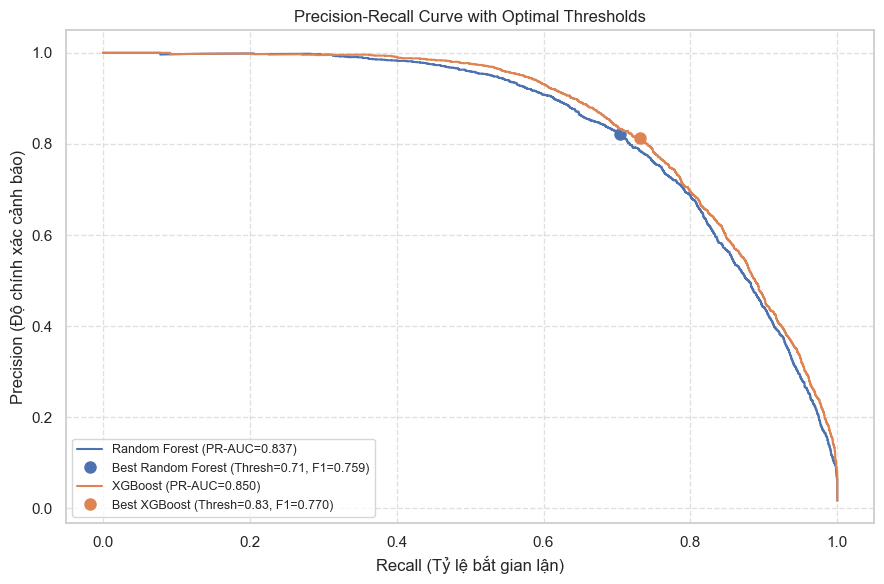

In [18]:
plt.figure(figsize=(9, 6))

best_thresholds = {}

for res in results:
    # 1. Tính Precision, Recall và Thresholds từ y_prob
    precisions, recalls, thresholds = precision_recall_curve(y_val, res["y_prob"])
    
    # 2. Tính F1-score cho mọi điểm Threshold (thêm 1e-10 để tránh chia cho 0)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    # 3. Tìm chỉ số (index) có F1-score cao nhất
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    best_prec = precisions[best_idx]
    best_rec = recalls[best_idx]
    
    # Lưu lại threshold để dùng dự đoán sau này
    best_thresholds[res['model']] = best_thresh
    
    # In thông số chi tiết ra console
    print(f"=== {res['model']} Optimal Threshold ===")
    print(f"-> Threshold: {best_thresh:.4f}")
    print(f"-> Max F1    : {best_f1:.4f} (Precision: {best_prec:.4f}, Recall: {best_rec:.4f})\n")
    
    # 4. Vẽ đường Precision-Recall Curve
    line, = plt.plot(recalls, precisions, label=f"{res['model']} (PR-AUC={res['pr_auc']:.3f})")
    
    # 5. Đánh dấu điểm Optimal Threshold lên đường cong
    plt.plot(best_rec, best_prec, 'o', color=line.get_color(), markersize=8,
             label=f"Best {res['model']} (Thresh={best_thresh:.2f}, F1={best_f1:.3f})")

# Cấu hình biểu đồ
plt.xlabel("Recall (Tỷ lệ bắt gian lận)")
plt.ylabel("Precision (Độ chính xác cảnh báo)")
plt.title("Precision-Recall Curve with Optimal Thresholds")
plt.legend(loc="lower left", fontsize=9)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## 6b. Bảng so sánh CUỐI — ở đúng threshold tối ưu (không phải 0.5)

Bảng ở mục 6 phía trên dùng `threshold=0.5` mặc định trong `evaluate_model()`.
ROC-AUC/PR-AUC không phụ thuộc threshold nên vẫn đúng, nhưng Precision/Recall/F1/FPR
ở mục 6 KHÔNG phản ánh đúng khả năng thật của model — vì threshold tối ưu
thực tế (tìm được ở mục ngay trên) là **0.67 (RF)** và **0.82 (XGB)**, không phải 0.5.
Bảng dưới đây tính lại đúng ở threshold tối ưu của từng model.


In [19]:
final_rows = []
for res in results:
    thresh = best_thresholds[res["model"]]
    y_pred_opt = (res["y_prob"] >= thresh).astype(int)

    p = precision_score(y_val, y_pred_opt)
    r = recall_score(y_val, y_pred_opt)
    f1 = f1_score(y_val, y_pred_opt)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred_opt).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    final_rows.append({
        "model": res["model"],
        "threshold": round(thresh, 4),
        "roc_auc": res["roc_auc"],
        "pr_auc": res["pr_auc"],
        "precision": p,
        "recall": r,
        "f1": f1,
        "fpr": fpr,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    })

df_final = pd.DataFrame(final_rows).sort_values("pr_auc", ascending=False)



print("\n=== BẢNG SO SÁNH Ở THRESHOLD TỐI ƯU ===")
display(df_final.round(4))



=== BẢNG SO SÁNH Ở THRESHOLD TỐI ƯU ===


,model,threshold,roc_auc,pr_auc,precision,recall,f1,fpr,TP,FP,FN,TN
1,XGBoost,0.8293,0.9938,0.8504,0.8139,0.7312,0.7703,0.0029,2489,569,915,196027
0,Random Forest,0.7069,0.9926,0.8368,0.8227,0.7048,0.7592,0.0026,2399,517,1005,196079


### ⚠️ 6c. Tách thêm calib_df / test_df — TRƯỚC khi calibrate

**Lỗi phát hiện khi review:** `CalibratedClassifierCV.fit(X_val, y_val)` ở mục 7
đang fit calibrator và ĐÁNH GIÁ calibrator trên CÙNG một tập `X_val`/`y_val`.
Đây là double-dipping — calibrator được học chính xác cách khớp với nhãn thật
của `X_val`, rồi bị đánh giá lại trên đúng tập đó. Bằng chứng: cột `Độ lệch
Prob (%)` trong bảng kết quả gần như 0.00000% cho mọi model calibrated —
gần như là tautology, không phải bằng chứng calibration tốt trên dữ liệu mới.

**Cách sửa:** tách `val_df` (giai đoạn 2024-05-26 → 2024-12-30) làm đôi theo
thời gian — nửa đầu dùng để FIT calibrator (`calib_df`), nửa sau dùng để
ĐÁNH GIÁ (`test_df`) — không bao giờ dùng chung 1 tập cho cả 2 việc.


In [20]:
# Tách val_df theo thời gian: nửa đầu = calib, nửa sau = test (đánh giá cuối)
calib_split_idx = int(len(val_df) * 0.5)
calib_df = val_df.iloc[:calib_split_idx]
test_df = val_df.iloc[calib_split_idx:]

X_calib = calib_df[FEATURE_COLS].fillna(train_median)
y_calib = calib_df["is_fraud"].copy()

X_test = test_df[FEATURE_COLS].fillna(train_median)
y_test = test_df["is_fraud"].copy()

print("Calib:", X_calib.shape, f"| {calib_df[TIME_COL].min()} -> {calib_df[TIME_COL].max()}")
print("Test :", X_test.shape,  f"| {test_df[TIME_COL].min()} -> {test_df[TIME_COL].max()}")
print("\nCalib fraud rate:", round(y_calib.mean() * 100, 3), "%")
print("Test fraud rate :", round(y_test.mean() * 100, 3), "%")


Calib: (100000, 24) | 2024-05-26 13:42:35 -> 2024-09-12 16:01:25
Test : (100000, 24) | 2024-09-12 16:01:51 -> 2024-12-30 23:59:34

Calib fraud rate: 1.761 %
Test fraud rate : 1.643 %


## 7. Probability Calibration (CalibratedClassifierCV)

### 💡 Tại sao bài toán Fraud Detection BẮT BUỘC cần Calibration?

1. **Hiện tượng lệch xác suất (Probability Distortion) khi xử lý Imbalanced Data**:
   - Cả hai mô hình Random Forest (`class_weight`) và XGBoost (`scale_pos_weight`) đều được áp dụng kỹ thuật **up-weighting lớp thiểu số (Fraud)** để tăng độ nhạy (Recall).
   - Tác dụng phụ: Xác suất đầu ra (`predict_proba`) bị **phóng đại / dịch chuyển sang phải (overconfident)**. Ví dụ: một giao dịch có xác suất dự đoán $0.70$ nhưng thực tế xác suất gian lận thực nghiệm có thể chỉ là $0.15 - 0.20$.
   - Đó là lý do tại sao ở mục 6b, threshold tối ưu F1 bị đẩy lên rất cao (**0.71 với RF** và **0.83 với XGBoost** thay vì mốc chuẩn $0.50$).

2. **Ý nghĩa thực tế trong hệ thống Fraud Engine Production**:
   - **Xếp tầng rủi ro (Risk-based Routing / Scorecard)**: Hệ thống cần xác suất thật để phân luồng tự động:
     + $P(\text{Fraud}) < 0.05$: Giao dịch an toàn $\rightarrow$ **Tự động duyệt (Auto-Approve)**.
     + $0.05 \le P(\text{Fraud}) < 0.30$: Rủi ro trung bình $\rightarrow$ **Xác thực 2FA / OTP (Step-up Auth)**.
     + $0.30 \le P(\text{Fraud}) < 0.70$: Rủi ro cao $\rightarrow$ **Chuyển điều tra viên (Manual Review)**.
     + $P(\text{Fraud}) \ge 0.70$: Gian lận rõ ràng $\rightarrow$ **Tự động chặn tức thì (Auto-Decline)**.
   - **Tính toán tổn thất kỳ vọng (Expected Loss)**: $\text{Expected Loss} = P(\text{Fraud}) \times \text{Amount}$ (chỉ tính chính xác khi xác suất đã được hiệu chuẩn).

3. **Hai phương pháp Calibration trong `CalibratedClassifierCV`**:
   - **Sigmoid (Platt Scaling)**: Sử dụng hàm Logistic để ánh xạ điểm dự đoán thành xác suất. Rất hiệu quả khi đường cong xác suất có dạng S-shape và chống overfit tốt.
   - **Isotonic Regression**: Phương pháp phi tham số (non-parametric), áp dụng hàm đơn điệu từng đoạn (piecewise non-decreasing). Linh hoạt hơn khi tập dữ liệu lớn.

In [21]:
# --- 7.1 KHỞI TẠO VÀ FIT CALIBRATEDCLASSIFIERCV ---
# QUAN TRỌNG: fit trên (X_calib, y_calib), ĐÁNH GIÁ trên (X_test, y_test)
# — KHÔNG bao giờ dùng chung 1 tập cho cả 2 việc (xem mục 6c).

try:
    from sklearn.frozen import FrozenEstimator
    def create_calibrator(base_clf, method='sigmoid'):
        return CalibratedClassifierCV(estimator=FrozenEstimator(base_clf), method=method)
except ImportError:
    def create_calibrator(base_clf, method='sigmoid'):
        return CalibratedClassifierCV(estimator=base_clf, method=method, cv='prefit')

# 1. Calibrate mô hình XGBoost (Best Model) — FIT trên calib
cal_xgb_sig = create_calibrator(xgb, method='sigmoid')
cal_xgb_sig.fit(X_calib, y_calib)

cal_xgb_iso = create_calibrator(xgb, method='isotonic')
cal_xgb_iso.fit(X_calib, y_calib)

# 2. Calibrate mô hình Random Forest — FIT trên calib
cal_rf_sig = create_calibrator(rf, method='sigmoid')
cal_rf_sig.fit(X_calib, y_calib)

cal_rf_iso = create_calibrator(rf, method='isotonic')
cal_rf_iso.fit(X_calib, y_calib)

# 3. Tổng hợp dự đoán xác suất — ĐÁNH GIÁ trên test (chưa từng dùng để fit gì)
models_eval = {
    'XGBoost (Raw)': (xgb, xgb.predict_proba(X_test)[:, 1]),
    'XGBoost (Sigmoid Calibrated)': (cal_xgb_sig, cal_xgb_sig.predict_proba(X_test)[:, 1]),
    'XGBoost (Isotonic Calibrated)': (cal_xgb_iso, cal_xgb_iso.predict_proba(X_test)[:, 1]),
    'Random Forest (Raw)': (rf, rf.predict_proba(X_test)[:, 1]),
    'Random Forest (Sigmoid Calibrated)': (cal_rf_sig, cal_rf_sig.predict_proba(X_test)[:, 1]),
    'Random Forest (Isotonic Calibrated)': (cal_rf_iso, cal_rf_iso.predict_proba(X_test)[:, 1]),
}

# 4. Đánh giá Brier Score, PR-AUC, ROC-AUC và Mean Probability — TRÊN TEST
calib_summary = []
actual_fraud_rate = float(y_test.mean())

for name, (m, prob) in models_eval.items():
    brier = brier_score_loss(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)
    roc_auc = roc_auc_score(y_test, prob)
    mean_prob = prob.mean()

    calib_summary.append({
        'Mô hình': name,
        'Brier Score (Càng thấp càng tốt)': brier,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc,
        'Mean Predicted Prob': mean_prob,
        'Actual Fraud Rate': actual_fraud_rate,
        'Độ lệch Prob (%)': abs(mean_prob - actual_fraud_rate) / actual_fraud_rate * 100
    })

df_calib = pd.DataFrame(calib_summary)
print("=== BẢNG SO SÁNH HIỆU QUẢ PROBABILITY CALIBRATION (đánh giá trên TEST, không phải calib) ===")
display(df_calib.round(5))


=== BẢNG SO SÁNH HIỆU QUẢ PROBABILITY CALIBRATION (đánh giá trên TEST, không phải calib) ===


,Mô hình,Brier Score (Càng thấp càng tốt),PR-AUC,ROC-AUC,Mean Predicted Prob,Actual Fraud Rate,Độ lệch Prob (%)
0,XGBoost (Raw),0.01041,0.84685,0.99371,0.03488,0.01643,112.30922
1,XGBoost (Sigmoid Calibrated),0.00599,0.84685,0.99371,0.01701,0.01643,3.52500
2,XGBoost (Isotonic Calibrated),0.00551,0.83620,0.99370,0.01703,0.01643,3.64546
3,Random Forest (Raw),0.00887,0.83244,0.99237,0.03690,0.01643,124.58989
4,Random Forest (Sigmoid Calibrated),0.00591,0.83244,0.99237,0.01691,0.01643,2.90391
5,Random Forest (Isotonic Calibrated),0.00577,0.82066,0.99220,0.01693,0.01643,3.04413


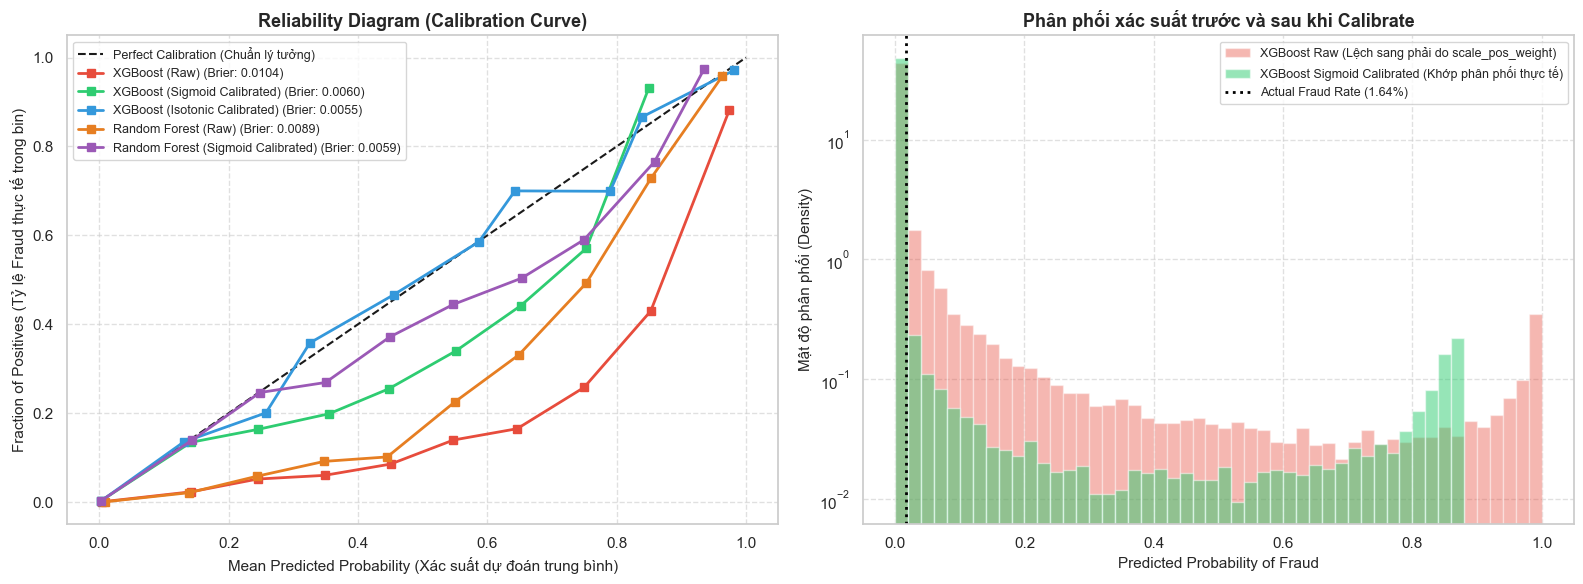

In [22]:
# --- 7.2 TRỰC QUAN HÓA CALIBRATION CURVES (RELIABILITY DIAGRAMS) ---

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Calibration Curve (Reliability Diagram)
ax1 = axes[0]
ax1.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration (Chuẩn lý tưởng)', linewidth=1.5)

colors = {
    'XGBoost (Raw)': '#e74c3c',
    'XGBoost (Sigmoid Calibrated)': '#2ecc71',
    'XGBoost (Isotonic Calibrated)': '#3498db',
    'Random Forest (Raw)': '#e67e22',
    'Random Forest (Sigmoid Calibrated)': '#9b59b6'
}

for name, (m, prob) in models_eval.items():
    if name in colors:
        fraction_of_positives, mean_predicted_value = calibration_curve(y_test, prob, n_bins=10)
        ax1.plot(
            mean_predicted_value, fraction_of_positives, "s-",
            label=f"{name} (Brier: {brier_score_loss(y_test, prob):.4f})",
            color=colors[name],
            linewidth=2
        )

ax1.set_xlabel("Mean Predicted Probability (Xác suất dự đoán trung bình)", fontsize=11)
ax1.set_ylabel("Fraction of Positives (Tỷ lệ Fraud thực tế trong bin)", fontsize=11)
ax1.set_title("Reliability Diagram (Calibration Curve)", fontsize=13, fontweight='bold')
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, linestyle="--", alpha=0.6)

# 2. Phân phối xác suất dự đoán (Predicted Probabilities Distribution)
ax2 = axes[1]
ax2.hist(
    models_eval['XGBoost (Raw)'][1], bins=50, range=(0, 1), density=True,
    alpha=0.4, color='#e74c3c', label='XGBoost Raw (Lệch sang phải do scale_pos_weight)'
)
ax2.hist(
    models_eval['XGBoost (Sigmoid Calibrated)'][1], bins=50, range=(0, 1), density=True,
    alpha=0.5, color='#2ecc71', label='XGBoost Sigmoid Calibrated (Khớp phân phối thực tế)'
)
ax2.axvline(actual_fraud_rate, color='black', linestyle=':', linewidth=2, label=f'Actual Fraud Rate ({actual_fraud_rate*100:.2f}%)')

ax2.set_xlabel("Predicted Probability of Fraud", fontsize=11)
ax2.set_ylabel("Mật độ phân phối (Density)", fontsize=11)
ax2.set_title("Phân phối xác suất trước và sau khi Calibrate", fontsize=13, fontweight='bold')
ax2.set_yscale('log')  # Log scale để nhìn rõ đuôi phân phối gian lận
ax2.legend(loc="upper right", fontsize=9)
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


In [23]:
# --- 7.3 PHÂN LUỒNG RỦI RO THỰC TẾ (RISK TIERING / DECISION ENGINE) ---
# Sau khi calibrate, xác suất có thể dùng trực tiếp để phân luồng quyết định

best_cal_model = cal_xgb_sig
y_prob_cal = best_cal_model.predict_proba(X_test)[:, 1]  # ĐÁNH GIÁ trên test, không phải val

# Thiết lập 4 tầng rủi ro cho hệ thống Fraud Detection
def assign_risk_tier(prob):
    if prob < 0.05:
        return '1. Low Risk (Auto-Approve)'
    elif prob < 0.30:
        return '2. Medium Risk (Step-up 2FA / OTP)'
    elif prob < 0.70:
        return '3. High Risk (Manual Review / Queue)'
    else:
        return '4. Critical Risk (Auto-Decline)'

df_tiers = pd.DataFrame({
    'prob': y_prob_cal,
    'is_fraud': y_test.values
})
df_tiers['risk_tier'] = df_tiers['prob'].apply(assign_risk_tier)

tier_summary = df_tiers.groupby('risk_tier').agg(
    total_tx=('is_fraud', 'count'),
    fraud_tx=('is_fraud', 'sum'),
    empirical_fraud_rate=('is_fraud', 'mean'),
    avg_predicted_prob=('prob', 'mean')
).reset_index()

tier_summary['pct_of_total_tx'] = tier_summary['total_tx'] / len(df_tiers) * 100
tier_summary['pct_of_total_fraud'] = tier_summary['fraud_tx'] / df_tiers['is_fraud'].sum() * 100

print("=== BẢNG PHÂN LUỒNG QUYẾT ĐỊNH RỦI RO TRÊN TẬP TEST (holdout thật) ===")
display(tier_summary.round(4))


=== BẢNG PHÂN LUỒNG QUYẾT ĐỊNH RỦI RO TRÊN TẬP TEST (holdout thật) ===


,risk_tier,total_tx,fraud_tx,empirical_fraud_rate,avg_predicted_prob,pct_of_total_tx,pct_of_total_fraud
0,1. Low Risk (Auto-Approve),97125,194.0,0.0020,0.0016,97.125,11.8077
1,2. Medium Risk (Step-up 2FA / OTP),928,121.0,0.1304,0.1357,0.928,7.3646
2,3. High Risk (Manual Review / Queue),627,199.0,0.3174,0.5118,0.627,12.1120
3,4. Critical Risk (Auto-Decline),1320,1129.0,0.8553,0.8293,1.320,68.7158


## 8. Feature Importance (model tốt nhất)


Best model: XGBoost


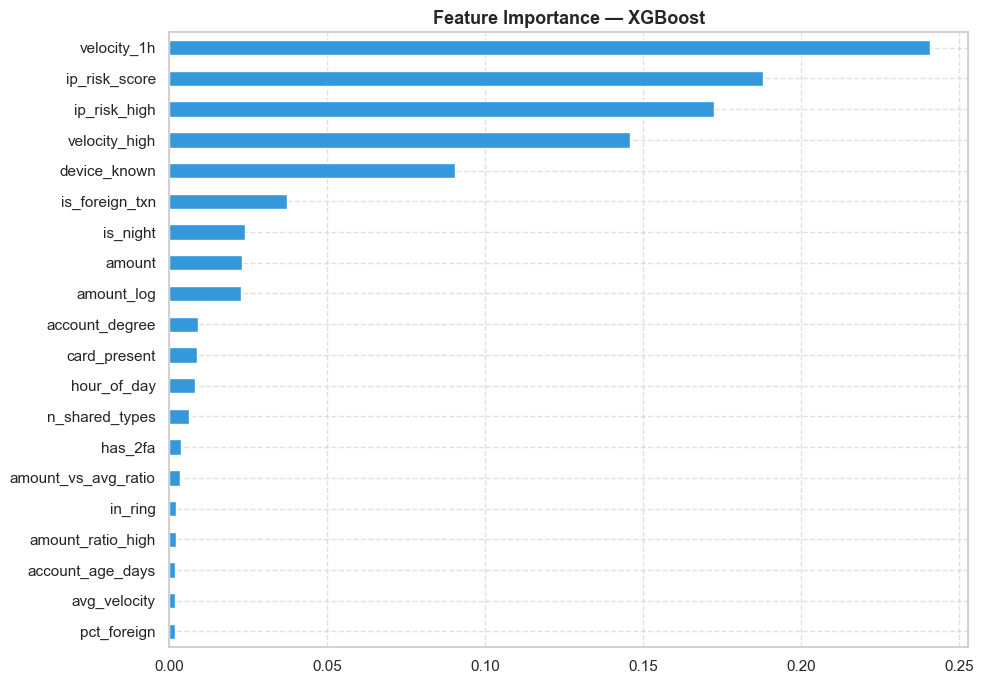


Top 15 features:
velocity_1h            0.240860
ip_risk_score          0.188042
ip_risk_high           0.172457
velocity_high          0.145784
device_known           0.090529
is_foreign_txn         0.037177
is_night               0.024059
amount                 0.023026
amount_log             0.022883
account_degree         0.009032
card_present           0.008823
hour_of_day            0.008060
n_shared_types         0.006411
has_2fa                0.003910
amount_vs_avg_ratio    0.003366
dtype: float32


In [24]:
best_model = None
best_name = ""

if res_xgb is not None and res_xgb["pr_auc"] >= res_rf["pr_auc"]:
    best_model = xgb
    best_name = "XGBoost"
    best_calibrated = cal_xgb_sig
else:
    best_model = rf
    best_name = "Random Forest"
    best_calibrated = cal_rf_sig

print(f"Best model: {best_name}")

if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=FEATURE_COLS)
    imp = imp.sort_values(ascending=False)

    plt.figure(figsize=(10, 7))
    imp.head(20).plot(kind="barh", color="#3498db")
    plt.title(f"Feature Importance — {best_name}", fontsize=13, fontweight="bold")
    plt.gca().invert_yaxis()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    print("\nTop 15 features:")
    print(imp.head(15))


## 9. Lưu model và artifact

Lưu cả model nguyên bản, model đã được calibrate xác suất (phục vụ production API/Agent), danh sách features và ngưỡng tối ưu.


In [25]:
import joblib

# 1. Lưu base model tốt nhất
base_model_path = MODEL_DIR / f"baseline_{best_name.lower().replace(' ', '_')}.pkl"
joblib.dump(best_model, base_model_path)

# 2. Lưu Calibrated model tốt nhất (xác suất chuẩn hóa)
calibrated_model_path = MODEL_DIR / f"baseline_{best_name.lower().replace(' ', '_')}_calibrated.pkl"
joblib.dump(best_calibrated, calibrated_model_path)

# 3. Lưu danh sách feature chuẩn
joblib.dump(FEATURE_COLS, MODEL_DIR / "feature_cols.pkl")

print("Đã lưu thành công các artifact:")
print(f"  -> Base Model        : {base_model_path}")
print(f"  -> Calibrated Model  : {calibrated_model_path}")
print(f"  -> Feature Columns   : {MODEL_DIR / 'feature_cols.pkl'}")


Đã lưu thành công các artifact:
  -> Base Model        : ..\models\baseline_xgboost.pkl
  -> Calibrated Model  : ..\models\baseline_xgboost_calibrated.pkl
  -> Feature Columns   : ..\models\feature_cols.pkl
